In [1]:
import os
import sys
import glob
import joblib
import random
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from sklearn.metrics import log_loss, accuracy_score, mean_absolute_error
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Setup Directories (Assuming notebook is in the project root)
BASE_DIR = Path("..").resolve()
MODELS_DIR = BASE_DIR / "models"
DATA_DIR = BASE_DIR / "data"

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(DATA_DIR / "world_cup_prediction_dataset", exist_ok=True)

print("Libraries imported and directories verified.")

Libraries imported and directories verified.


In [2]:
class EloSystem:
    def __init__(self, base_k=20, home_advantage=100):
        self.ratings = {}
        self.base_k = base_k
        self.home_advantage = home_advantage

    def get_expected_score(self, rating_a, rating_b):
        """Calculates expected win probability using the Elo formula."""
        return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

    def get_k_factor(self, tournament):
        """Dynamic K-Factor: World Cup matches shift Elo drastically, friendlies barely move it."""
        weights = {
            "FIFA World Cup": 60,
            "UEFA Euro": 50,
            "Copa América": 50,
            "AFC Asian Cup": 40,
            "African Cup of Nations": 40,
            "UEFA Nations League": 30,
            "Friendly": 20
        }
        return weights.get(tournament, 30)

    def get_gd_multiplier(self, margin):
        """Goal Difference Multiplier: Rewards blowouts (e.g., 3-0) over narrow 1-0 wins."""
        if margin <= 1:
            return 1.0
        elif margin == 2:
            return 1.5
        else:
            return (11 + margin) / 8.0

    def process_matches(self, df):
        """Iterates through historical matches sequentially to build dynamic Elo ratings."""
        ledger = []
        
        for _, row in df.iterrows():
            home, away = row['HomeTeam'], row['AwayTeam']
            hg, ag = row['HomeGoals'], row['AwayGoals']
            tourn = row['tournament']
            neutral = row.get('neutral', False)

            # Initialize teams at 1500 if it's their first match
            if home not in self.ratings: self.ratings[home] = 1500
            if away not in self.ratings: self.ratings[away] = 1500

            home_elo, away_elo = self.ratings[home], self.ratings[away]

            # 1. Record the pre-match Elo for the training ledger
            ledger.append({
                'Date': row['Date'],
                'HomeTeam': home,
                'AwayTeam': away,
                'HomeElo': home_elo,
                'AwayElo': away_elo
            })

            # If match hasn't happened yet (or missing goals), skip update
            if pd.isna(hg) or pd.isna(ag):
                continue

            # 2. Calculate Expected Outcome
            # Apply Home Advantage (+100) if it's not a neutral venue
            ha = self.home_advantage if not neutral else 0
            exp_home = self.get_expected_score(home_elo + ha, away_elo)
            exp_away = self.get_expected_score(away_elo, home_elo + ha)

            # 3. Calculate Actual Outcome
            if hg > ag:
                s_home, s_away = 1.0, 0.0
            elif hg < ag:
                s_home, s_away = 0.0, 1.0
            else:
                s_home, s_away = 0.5, 0.5

            # 4. Calculate Adjustments
            k = self.get_k_factor(tourn)
            gd = self.get_gd_multiplier(abs(hg - ag))

            # 5. Apply Updates
            self.ratings[home] = home_elo + k * gd * (s_home - exp_home)
            self.ratings[away] = away_elo + k * gd * (s_away - exp_away)

        return pd.DataFrame(ledger)

print("EloSystem class successfully loaded into memory.")

EloSystem class successfully loaded into memory.


In [3]:
def compute_rolling_form(matches_df, window=5):
    df = matches_df.sort_values('Date').reset_index(drop=True)
    if "tournament" not in df.columns: df["tournament"] = "FIFA World Cup"
        
    weights = {"FIFA World Cup": 5, "UEFA Euro": 4, "Copa América": 4, "AFC Asian Cup": 3, "African Cup of Nations": 3, "UEFA Nations League": 2, "Friendly": 1}
    df["TournamentWeight"] = df["tournament"].map(weights).fillna(2)
    
    home_side = df[['Date', 'HomeTeam', 'HomeGoals', 'AwayGoals']].rename(columns={'HomeTeam': 'Team', 'HomeGoals': 'GoalsScored', 'AwayGoals': 'GoalsConceded'})
    home_side['IsHome'], home_side['Points'] = 1, np.where(home_side['GoalsScored'] > home_side['GoalsConceded'], 3, np.where(home_side['GoalsScored'] == home_side['GoalsConceded'], 1, 0))
    home_side["WeightedPoints"] = home_side["Points"] * df["TournamentWeight"]
    
    away_side = df[['Date', 'AwayTeam', 'AwayGoals', 'HomeGoals']].rename(columns={'AwayTeam': 'Team', 'AwayGoals': 'GoalsScored', 'HomeGoals': 'GoalsConceded'})
    away_side['IsHome'], away_side['Points'] = 0, np.where(away_side['GoalsScored'] > away_side['GoalsConceded'], 3, np.where(away_side['GoalsScored'] == away_side['GoalsConceded'], 1, 0))
    away_side["WeightedPoints"] = away_side["Points"] * df["TournamentWeight"]
    
    team_history = pd.concat([home_side, away_side]).sort_values('Date')
    grouped = team_history.groupby('Team')

    team_history['Rolling_Pts_Avg'] = grouped['Points'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    team_history['Rolling_Pts_5'] = grouped['Points'].transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    team_history['Rolling_Pts_10'] = grouped['Points'].transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
    team_history['Rolling_Pts_20'] = grouped['Points'].transform(lambda x: x.shift(1).rolling(20, min_periods=1).mean())
    team_history['Momentum'] = grouped['Points'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    team_history["Rolling_Weighted_Pts"] = grouped["WeightedPoints"].transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    team_history['Weighted_Form'] = grouped['Points'].transform(lambda x: x.shift(1).ewm(span=5, min_periods=1).mean())
    team_history['Rolling_GS_Avg'] = grouped['GoalsScored'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    team_history['Rolling_GC_Avg'] = grouped['GoalsConceded'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    
    team_history.fillna({'Rolling_Pts_Avg': 1.0, 'Rolling_GS_Avg': 1.0, 'Rolling_GC_Avg': 1.0, 'Rolling_Pts_5': 1.0, 'Rolling_Pts_10': 1.0, 'Rolling_Pts_20': 1.0, 'Momentum': 1.0, 'Rolling_Weighted_Pts': 1.0, 'Weighted_Form': 1.0}, inplace=True)
    
    df = pd.merge(df, team_history[team_history['IsHome'] == 1][['Date', 'Team', 'Rolling_Pts_Avg', 'Rolling_Pts_5', 'Rolling_Pts_10', 'Rolling_Pts_20', 'Rolling_Weighted_Pts', 'Weighted_Form', 'Momentum', 'Rolling_GS_Avg', 'Rolling_GC_Avg']], left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], how='left').rename(columns={'Rolling_Pts_Avg': 'Home_Form_Pts', 'Rolling_Pts_5': 'Home_Form5', 'Rolling_Pts_10': 'Home_Form10', 'Rolling_Pts_20': 'Home_Form20', 'Rolling_Weighted_Pts': 'Home_Rolling_Weighted_Pts', 'Weighted_Form': 'Home_Weighted_Form', 'Momentum': 'Home_Momentum', 'Rolling_GS_Avg': 'Home_Form_GS', 'Rolling_GC_Avg': 'Home_Form_GC'}).drop(columns=['Team'])
    df = pd.merge(df, team_history[team_history['IsHome'] == 0][['Date', 'Team', 'Rolling_Pts_Avg', 'Rolling_Pts_5', 'Rolling_Pts_10', 'Rolling_Pts_20', 'Rolling_Weighted_Pts', 'Weighted_Form', 'Momentum', 'Rolling_GS_Avg', 'Rolling_GC_Avg']], left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], how='left').rename(columns={'Rolling_Pts_Avg': 'Away_Form_Pts', 'Rolling_Pts_5': 'Away_Form5', 'Rolling_Pts_10': 'Away_Form10', 'Rolling_Pts_20': 'Away_Form20', 'Rolling_Weighted_Pts': 'Away_Rolling_Weighted_Pts', 'Weighted_Form': 'Away_Weighted_Form', 'Momentum': 'Away_Momentum', 'Rolling_GS_Avg': 'Away_Form_GS', 'Rolling_GC_Avg': 'Away_Form_GC'}).drop(columns=['Team'])
    return df

def extract_form_ledger(df_with_form):
    form_cols = ['Form_Pts', 'Form5', 'Form10', 'Form20', 'Rolling_Weighted_Pts', 'Weighted_Form', 'Momentum', 'Form_GS', 'Form_GC']
    home_cols, away_cols = ['Date', 'HomeTeam'] + ['Home_' + col for col in form_cols], ['Date', 'AwayTeam'] + ['Away_' + col for col in form_cols]
    home_records, away_records = df_with_form[home_cols].copy(), df_with_form[away_cols].copy()
    home_records.columns, away_records.columns = ['Date', 'Team'] + form_cols, ['Date', 'Team'] + form_cols
    return pd.concat([home_records, away_records]).sort_values('Date').dropna()

def build_comprehensive_features(matches, elo_ledger, rankings, squad_stats, wc_history, wc_profiles, penalty_df):
    df = matches.copy()
    df = pd.merge(df, wc_history.add_prefix('Home_'), left_on='HomeTeam', right_on='Home_Team', how='left')
    df = pd.merge(df, wc_history.add_prefix('Away_'), left_on='AwayTeam', right_on='Away_Team', how='left')
    df.fillna({'Home_WC_Titles': 0, 'Away_WC_Titles': 0}, inplace=True)
    
    home_wc = wc_profiles.rename(columns={"Team": "HomeTeam", "WC_Matches": "Home_WC_Matches", "WC_Wins": "Home_WC_Wins", "WC_Draws": "Home_WC_Draws", "WC_Losses": "Home_WC_Losses", "WC_GF": "Home_WC_GF", "WC_GA": "Home_WC_GA", "WC_GD": "Home_WC_GD", "WC_WinPct": "Home_WC_WinPct"})
    away_wc = wc_profiles.rename(columns={"Team": "AwayTeam", "WC_Matches": "Away_WC_Matches", "WC_Wins": "Away_WC_Wins", "WC_Draws": "Away_WC_Draws", "WC_Losses": "Away_WC_Losses", "WC_GF": "Away_WC_GF", "WC_GA": "Away_WC_GA", "WC_GD": "Away_WC_GD", "WC_WinPct": "Away_WC_WinPct"})
    df = pd.merge(df, home_wc, on="HomeTeam", how="left")
    df = pd.merge(df, away_wc, on="AwayTeam", how="left")
    df.fillna({"Home_WC_Matches": 0, "Away_WC_Matches": 0, "Home_WC_Wins": 0, "Away_WC_Wins": 0, "Home_WC_GF": 0, "Away_WC_GF": 0, "Home_WC_GA": 0, "Away_WC_GA": 0, "Home_WC_GD": 0, "Away_WC_GD": 0, "Home_WC_WinPct": 0, "Away_WC_WinPct": 0}, inplace=True)
    
    df = pd.merge(df, elo_ledger[['Date', 'HomeTeam', 'AwayTeam', 'HomeElo', 'AwayElo']], on=['Date', 'HomeTeam', 'AwayTeam'], how='left').rename(columns={'HomeElo': 'Home_Elo', 'AwayElo': 'Away_Elo'})
    df, rankings, squad_stats = df.sort_values('Date'), rankings.sort_values('Date'), squad_stats.sort_values('Date')
    df = pd.merge_asof(df, rankings[['Date', 'Team', 'Rank', 'Points']].add_prefix('Home_'), left_on='Date', right_on='Home_Date', left_by='HomeTeam', right_by='Home_Team', direction='backward')
    df = pd.merge_asof(df, rankings[['Date', 'Team', 'Rank', 'Points']].add_prefix('Away_'), left_on='Date', right_on='Away_Date', left_by='AwayTeam', right_by='Away_Team', direction='backward')
    df = pd.merge_asof(df, squad_stats.add_prefix('Home_'), left_on='Date', right_on='Home_Date', left_by='HomeTeam', right_by='Home_Team', direction='backward')
    df = pd.merge_asof(df, squad_stats.add_prefix('Away_'), left_on='Date', right_on='Away_Date', left_by='AwayTeam', right_by='Away_Team', direction='backward')

    df['Elo_Delta'] = df['Home_Elo'] - df['Away_Elo']
    df['Rank_Delta'] = df['Away_Rank'] - df['Home_Rank']
    df['Points_Delta'] = df['Home_Points'] - df['Away_Points']
    df["WC_Matches_Delta"] = df["Home_WC_Matches"] - df["Away_WC_Matches"]
    df["WC_Wins_Delta"] = df["Home_WC_Wins"] - df["Away_WC_Wins"]
    df["WC_GD_Delta"] = df["Home_WC_GD"] - df["Away_WC_GD"]
    df["WC_WinPct_Delta"] = df["Home_WC_WinPct"] - df["Away_WC_WinPct"]
    df['OVR_11_Delta'] = df['Home_Avg_OVR_Top11'] - df['Away_Avg_OVR_Top11']
    df['Value_Delta'] = np.log1p(df['Home_Total_Value_Top23']) - np.log1p(df['Away_Total_Value_Top23'])
    df['WC_Pedigree_Delta'] = df['Home_WC_Titles'] - df['Away_WC_Titles']
    df['Form_Pts_Delta'] = df['Home_Form_Pts'] - df['Away_Form_Pts']
    df['Form_GS_Delta'] = df['Home_Form_GS'] - df['Away_Form_GS']
    df['Form_GC_Delta'] = df['Home_Form_GC'] - df['Away_Form_GC']
    df["Goal_Diff_Form"] = df["Form_GS_Delta"] - df["Form_GC_Delta"]
    
    df = pd.merge(df, penalty_df.rename(columns={"Team": "HomeTeam", "Penalty_Rating": "Home_Penalty_Rating"})[["HomeTeam", "Home_Penalty_Rating"]], on="HomeTeam", how="left")
    df = pd.merge(df, penalty_df.rename(columns={"Team": "AwayTeam", "Penalty_Rating": "Away_Penalty_Rating"})[["AwayTeam", "Away_Penalty_Rating"]], on="AwayTeam", how="left")
    df["Home_Penalty_Rating"] = df["Home_Penalty_Rating"].fillna(0.5)
    df["Away_Penalty_Rating"] = df["Away_Penalty_Rating"].fillna(0.5)
    df["Penalty_Delta"] = df["Home_Penalty_Rating"] - df["Away_Penalty_Rating"]
    
    df["Form5_Delta"] = df["Home_Form5"] - df["Away_Form5"]
    df["Weighted_Form_Delta"] = df["Home_Rolling_Weighted_Pts"] - df["Away_Rolling_Weighted_Pts"]
    df["Form10_Delta"] = df["Home_Form10"] - df["Away_Form10"]
    df["Form20_Delta"] = df["Home_Form20"] - df["Away_Form20"]
    df["Momentum_Delta"] = df["Home_Momentum"] - df["Away_Momentum"]
    
    return df.dropna(subset=['Elo_Delta', 'Rank_Delta', 'OVR_11_Delta'])

print("Feature Engineering logic loaded.")

Feature Engineering logic loaded.


In [4]:
def train_time_series_models(df):
    features = [
        "Elo_Delta", "OVR_11_Delta", "Value_Delta",
        "WC_Pedigree_Delta", "Home_Form_Pts", "Away_Form_Pts", "Form_Pts_Delta",
        "Form_GS_Delta", "Form_GC_Delta", "Goal_Diff_Form", "Weighted_Form_Delta",
        "Form5_Delta", "Form10_Delta", "Form20_Delta", "Momentum_Delta", "neutral" 
    ]
    optional = ["Star_Power_Delta", "Age_Delta", "Value_23_Log_Delta", "Form3_Delta"]
    for col in optional:
        if col in df.columns: features.append(col)
    features = [c for c in features if c in df.columns]

    if "neutral" in df.columns: df["neutral"] = df["neutral"].astype(int)

    train = df[df["Date"] < "2018-01-01"]
    val = df[(df["Date"] >= "2018-01-01") & (df["Date"] < "2022-01-01")]
    test = df[df["Date"] >= "2022-01-01"]

    X_train, X_val, X_test = train[features], val[features], test[features]
    y_train, y_val, y_test = train["Target"], val["Target"], test["Target"]

    # --- 1. Logistic Regression ---
    clf_lr = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, random_state=42))
    ])

    # --- 2. Random Forest (Forced to Diversify) ---
    clf_rf = RandomForestClassifier(
        n_estimators=800, 
        max_depth=5,            # LOWER: Prevents Elo from dominating the whole tree
        max_features=0.3,       # CRITICAL: Only allowed to see 30% of features per split
        min_samples_leaf=6, 
        random_state=42
    )

    # --- 3. XGBoost (Aggressively Restricted) ---
    clf_xgb = xgb.XGBClassifier(
        objective="multi:softprob", num_class=3, n_estimators=1500,
        learning_rate=0.015, 
        max_depth=4,            # SHALLOW: Forces the model to use different features
        min_child_weight=3,
        gamma=1.0,              # HIGHER: Makes it harder to split, stopping Elo obsession
        subsample=0.8, 
        colsample_bytree=0.4,   # Only 40% of features given to each tree
        colsample_bylevel=0.5,  # Only 50% of those given to each node!
        random_state=42
    )

    # --- 4. The Voting Ensemble ---
    ensemble_clf = VotingClassifier(
        estimators=[
            ('lr', clf_lr),
            ('rf', clf_rf),
            ('xgb', clf_xgb)
        ],
        voting='soft',
        weights=[1, 1, 1.5] # Give XGBoost a slight tie-breaking edge
    )

    # --- 5. Calibrate the entire Ensemble ---
    print("Training and Calibrating the Ensemble... (This will take a few minutes)")
    clf = CalibratedClassifierCV(estimator=ensemble_clf, method="isotonic", cv=5)
    clf.fit(X_train, y_train)
    clf.feature_names_in_ = X_train.columns.values

    print("Training Home Poisson xG Regressor...")
    reg_home = xgb.XGBRegressor(objective="count:poisson", n_estimators=500, learning_rate=0.02, max_depth=5, subsample=0.85, colsample_bytree=0.85, random_state=42)
    reg_home.fit(X_train, train["HomeGoals"], eval_set=[(X_val, val["HomeGoals"])], verbose=False)

    print("Training Away Poisson xG Regressor...")
    reg_away = xgb.XGBRegressor(objective="count:poisson", n_estimators=500, learning_rate=0.02, max_depth=5, subsample=0.85, colsample_bytree=0.85, random_state=42)
    reg_away.fit(X_train, train["AwayGoals"], eval_set=[(X_val, val["AwayGoals"])], verbose=False)

    probs, preds = clf.predict_proba(X_test), clf.predict(X_test)
    print("\n=== TEST PERFORMANCE ===")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Log Loss:", log_loss(y_test, probs))
    print("Home Goal MAE:", mean_absolute_error(test["HomeGoals"], reg_home.predict(X_test)))
    print("Away Goal MAE:", mean_absolute_error(test["AwayGoals"], reg_away.predict(X_test)))

    return clf, reg_home, reg_away

print("Model Training logic loaded.")

Model Training logic loaded.


In [5]:
def predict_match(home_team, away_team, team_profiles, clf, reg_home, reg_away):
    if home_team not in team_profiles.index or away_team not in team_profiles.index: return None

    home, away = team_profiles.loc[home_team], team_profiles.loc[away_team]
    X = pd.DataFrame([{
        "Elo_Delta": home.get("Elo", 1500) - away.get("Elo", 1500),
        "Rank_Delta": away.get("Rank", 50) - home.get("Rank", 50),
        "Points_Delta": home.get("Points", 1400) - away.get("Points", 1400),
        "OVR_11_Delta": home.get("OVR11", 75) - away.get("OVR11", 75),
        "Value_Delta": np.log1p(home.get("Value", 1000000)) - np.log1p(away.get("Value", 1000000)),
        "WC_Pedigree_Delta": home.get("WC_Titles", 0) - away.get("WC_Titles", 0),
        "Home_Form_Pts": home.get("Form_Pts", 1.0), "Away_Form_Pts": away.get("Form_Pts", 1.0),
        "Form_Pts_Delta": home.get("Form_Pts", 1.0) - away.get("Form_Pts", 1.0),
        "Form_GS_Delta": home.get("Form_GS", 1.0) - away.get("Form_GS", 1.0),
        "Form_GC_Delta": home.get("Form_GC", 1.0) - away.get("Form_GC", 1.0),
        "Goal_Diff_Form": (home.get("Form_GS", 1.0) - away.get("Form_GS", 1.0)) - (home.get("Form_GC", 1.0) - away.get("Form_GC", 1.0)),
        "Weighted_Form_Delta": home.get("Rolling_Weighted_Pts", 1.0) - away.get("Rolling_Weighted_Pts", 1.0),
        "Form5_Delta": home.get("Form5", 1.0) - away.get("Form5", 1.0),
        "Form10_Delta": home.get("Form10", 1.0) - away.get("Form10", 1.0),
        "Form20_Delta": home.get("Form20", 1.0) - away.get("Form20", 1.0),
        "Momentum_Delta": home.get("Momentum", 1.0) - away.get("Momentum", 1.0),
        "neutral": 1
    }])[clf.feature_names_in_]

    probs = clf.predict_proba(X)[0]
    away_win_prob, draw_prob, home_win_prob = float(probs[0]), float(probs[1]), float(probs[2])
    
    home_xg, away_xg = max(0.1, float(reg_home.predict(X)[0])), max(0.1, float(reg_away.predict(X)[0]))
    strength = home_win_prob - away_win_prob
    home_xg, away_xg = max(home_xg * (1 + 0.30 * strength), 0.1), max(away_xg * (1 - 0.30 * strength), 0.1)

    penalty_home, penalty_away = float(home.get("Penalty_Rating", 0.5)), float(away.get("Penalty_Rating", 0.5))
    total = penalty_home + penalty_away if (penalty_home + penalty_away) > 0 else 1
    penalty_winner = home_team if (penalty_home / total) > 0.5 else away_team

    # Calculate Projected Winner based on highest probability
    max_prob = max(home_win_prob, draw_prob, away_win_prob)
    if max_prob == home_win_prob: projected_winner = home_team
    elif max_prob == away_win_prob: projected_winner = away_team
    else: projected_winner = "Draw"

    return {
        "probabilities": {"home_win": home_win_prob, "draw": draw_prob, "away_win": away_win_prob}, 
        "xg": {"home_xg": home_xg, "away_xg": away_xg}, 
        "knockout_prediction": {"winner": penalty_winner},
        "projected_winner": projected_winner
    }

# --- STEP 2: Poisson Match Simulator ---

def simulate_match(home, away, team_profiles, clf, reg_home, reg_away, deterministic=False):
    result = predict_match(home, away, team_profiles, clf, reg_home, reg_away)
    if result is None: return None

    home_xg = result["xg"]["home_xg"]
    away_xg = result["xg"]["away_xg"]
    probs = result["probabilities"]

    if deterministic:
        home_goals = int(round(home_xg))
        away_goals = int(round(away_xg))
        
        max_prob = max(probs["home_win"], probs["draw"], probs["away_win"])
        if max_prob == probs["home_win"]: expected_outcome = "H"
        elif max_prob == probs["away_win"]: expected_outcome = "A"
        else: expected_outcome = "D"
            
        if expected_outcome == "H" and home_goals <= away_goals:
            home_goals = away_goals + 1
        elif expected_outcome == "A" and away_goals <= home_goals:
            away_goals = home_goals + 1
        elif expected_outcome == "D" and home_goals != away_goals:
            avg = (home_goals + away_goals) // 2
            home_goals, away_goals = avg, avg
    else:
        home_goals = np.random.poisson(home_xg)
        away_goals = np.random.poisson(away_xg)

    if home_goals > away_goals: match_winner = home
    elif away_goals > home_goals: match_winner = away
    else: match_winner = "Draw"

    return {
        "home_goals": home_goals,
        "away_goals": away_goals,
        "probabilities": probs,
        "match_winner": match_winner,
        "xg": result["xg"] # <-- ADDED SO KNOCKOUT CAN SEE xG
    }

def simulate_group(group, teams, all_matches, fixtures_df, team_profiles, clf, reg_home, reg_away, deterministic=False):
    table = pd.DataFrame(0, index=teams, columns=["P", "W", "D", "L", "Pts", "GF", "GA", "GD"], dtype=int)
    for _, match_row in fixtures_df[fixtures_df["Group"] == group].sort_values("Matchday").iterrows():
        home, away = match_row["Home"], match_row["Away"]
        match_result = simulate_match(home, away, team_profiles, clf, reg_home, reg_away, deterministic)
        if match_result is None: continue

        hg, ag = match_result["home_goals"], match_result["away_goals"]
        outcome = "H" if hg > ag else "A" if ag > hg else "D"
        table.loc[home, "P"] += 1; table.loc[away, "P"] += 1
        table.loc[home, "GF"] += hg; table.loc[home, "GA"] += ag
        table.loc[away, "GF"] += ag; table.loc[away, "GA"] += hg

        if outcome == "H": table.loc[home, "Pts"] += 3; table.loc[home, "W"] += 1; table.loc[away, "L"] += 1; winner_team = home
        elif outcome == "A": table.loc[away, "Pts"] += 3; table.loc[away, "W"] += 1; table.loc[home, "L"] += 1; winner_team = away
        else: table.loc[home, "Pts"] += 1; table.loc[away, "Pts"] += 1; table.loc[home, "D"] += 1; table.loc[away, "D"] += 1; winner_team = "Draw"

        if deterministic and all_matches is not None:
            all_matches.append({"Stage": "Group", "Group": group, "Home": home, "Away": away, "HomeGoals": hg, "AwayGoals": ag, "Winner": winner_team, "HomeWinProb": match_result["probabilities"]["home_win"], "DrawProb": match_result["probabilities"]["draw"], "AwayWinProb": match_result["probabilities"]["away_win"]})

    table["GD"] = table["GF"] - table["GA"]
    return table.sort_values(["Pts", "GD", "GF"], ascending=False)

# --- STEP 4: Knockouts ---
def simulate_knockout(team1, team2, stage, all_matches, team_profiles, clf, reg_home, reg_away, deterministic=False):
    if team1 is None or team2 is None: return team1 if team1 else team2
    match_result = simulate_match(team1, team2, team_profiles, clf, reg_home, reg_away, deterministic)
    if match_result is None: return team1
    
    hg, ag = match_result["home_goals"], match_result["away_goals"]
    probs = match_result["probabilities"]
    
    if hg > ag: winner = team1
    elif ag > hg: winner = team2
    else:
        # --- NEW TIEBREAKER: Expected Goals (xG) ---
        home_xg = match_result["xg"]["home_xg"]
        away_xg = match_result["xg"]["away_xg"]
        total_xg = home_xg + away_xg
        
        if deterministic:
            # The team that created better chances physically advances
            winner = team1 if home_xg > away_xg else team2
        else:
            # Monte Carlo variance weighted by their xG ratio!
            winner = np.random.choice([team1, team2], p=[home_xg / total_xg, away_xg / total_xg])

    if deterministic and all_matches is not None:
        all_matches.append({"Stage": stage, "Home": team1, "Away": team2, "HomeGoals": hg, "AwayGoals": ag, "Winner": winner, "HomeWinProb": probs["home_win"], "DrawProb": probs["draw"], "AwayWinProb": probs["away_win"]})

    return winner

def simulate_world_cup(groups, fixtures_df, team_profiles, clf, reg_home, reg_away, deterministic=False):
    all_matches = [] if deterministic else None
    group_winners, group_runners, all_group_tables = {}, {}, {}

    for group in sorted(groups["Group"].unique()):
        teams = groups[groups["Group"] == group]["Team"].tolist()
        table = simulate_group(group, teams, all_matches, fixtures_df, team_profiles, clf, reg_home, reg_away, deterministic)
        all_group_tables[group] = table
        group_winners[group], group_runners[group] = table.index[0], table.index[1]

    third_place = [{"Group": g, "Team": t.index[2], "Pts": t.iloc[2]["Pts"], "GD": t.iloc[2]["GD"], "GF": t.iloc[2]["GF"]} for g, t in all_group_tables.items() if len(t) > 2]
    best_third_teams = pd.DataFrame(third_place).sort_values(["Pts", "GD", "GF"], ascending=False).head(8)["Team"].tolist()

    round_of_32 = [
        (group_winners.get("A"), best_third_teams[7] if len(best_third_teams) > 7 else None), (group_winners.get("B"), best_third_teams[6] if len(best_third_teams) > 6 else None),
        (group_winners.get("C"), best_third_teams[5] if len(best_third_teams) > 5 else None), (group_winners.get("D"), best_third_teams[4] if len(best_third_teams) > 4 else None),
        (group_winners.get("E"), best_third_teams[3] if len(best_third_teams) > 3 else None), (group_winners.get("F"), best_third_teams[2] if len(best_third_teams) > 2 else None),
        (group_winners.get("G"), best_third_teams[1] if len(best_third_teams) > 1 else None), (group_winners.get("H"), best_third_teams[0] if len(best_third_teams) > 0 else None),
        (group_runners.get("A"), group_runners.get("B")), (group_runners.get("C"), group_runners.get("D")), (group_runners.get("E"), group_runners.get("F")), (group_runners.get("G"), group_runners.get("H")),
        (group_winners.get("I"), group_runners.get("J")), (group_winners.get("K"), group_runners.get("L")), (group_winners.get("J"), group_runners.get("I")), (group_winners.get("L"), group_runners.get("K"))
    ]

    r32_teams = []
    round16 = []
    for t1, t2 in round_of_32:
        r32_teams.extend([t1, t2])
        round16.append(simulate_knockout(t1, t2, "Round of 32", all_matches, team_profiles, clf, reg_home, reg_away, deterministic))

    def play_round(teams, stage):
        return [simulate_knockout(teams[i], teams[i + 1], stage, all_matches, team_profiles, clf, reg_home, reg_away, deterministic) for i in range(0, len(teams), 2)]

    quarterfinals = play_round(round16, "Round of 16")
    semifinals = play_round(quarterfinals, "Quarterfinals")
    finalists = play_round(semifinals, "Semifinals")
    champion = simulate_knockout(finalists[0], finalists[1], "Final", all_matches, team_profiles, clf, reg_home, reg_away, deterministic)

    return {"Champion": champion, "Matches": all_matches, "GroupTables": all_group_tables, "Round32": [t for t in r32_teams if t is not None], "Round16": round16, "Quarterfinals": quarterfinals, "Semifinals": semifinals, "Finalists": finalists}

print("Simulator logic loaded.")

Simulator logic loaded.


In [6]:
TEAM_MAP = {
    "Korea Republic": "South Korea", "IR Iran": "Iran", "USA": "United States",
    "Côte d'Ivoire": "Ivory Coast", "Congo DR": "DR Congo", "Cape Verde Islands": "Cape Verde",
    "Cabo Verde": "Cape Verde", "Curacao": "Curaçao", "Czechia": "Czech Republic"
}

raw_matches = pd.read_csv(DATA_DIR / "international_matches" / "results.csv").rename(columns={"date": "Date", "home_team": "HomeTeam", "away_team": "AwayTeam", "home_score": "HomeGoals", "away_score": "AwayGoals"})
raw_matches["Date"] = pd.to_datetime(raw_matches["Date"])
raw_matches["HomeTeam"] = raw_matches["HomeTeam"].replace(TEAM_MAP)
raw_matches["AwayTeam"] = raw_matches["AwayTeam"].replace(TEAM_MAP)

wc_raw = pd.read_csv(DATA_DIR / "historical_world_cups" / "WorldCups.csv")
wc_raw["Winner"] = wc_raw["Winner"].replace(TEAM_MAP)
wc_history_df = wc_raw["Winner"].value_counts().reset_index()
wc_history_df.columns = ["Team", "WC_Titles"]

rankings_df = pd.read_csv(DATA_DIR / "international_matches" / "fifa_ranking.csv").rename(columns={"country_full": "Team", "rank": "Rank", "total_points": "Points"})
rankings_df["Date"] = pd.to_datetime(rankings_df["rank_date"])
rankings_df["Team"] = rankings_df["Team"].replace(TEAM_MAP)

squad_list = []
for file in glob.glob(str(DATA_DIR / "fifa_ratings" / "players_*.csv")):
    year_str = os.path.basename(file).replace("players_", "").replace(".csv", "")
    if not year_str.isdigit(): continue
    df_players = pd.read_csv(file, low_memory=False).sort_values("overall", ascending=False)
    nat_col = "nationality_name" if "nationality_name" in df_players.columns else "nationality"
    val_col = "value_eur" if "value_eur" in df_players.columns else "value"

    def get_squad_metrics(group):
        t11, t23 = group.head(11), group.head(23)
        return pd.Series({"Avg_OVR_Top11": t11["overall"].mean(), "Total_Value_Top23": t23[val_col].sum() if val_col in group.columns else 0, "Avg_Age": t23["age"].mean()})

    squad_metrics = df_players.groupby(nat_col).apply(get_squad_metrics, include_groups=False).reset_index().rename(columns={nat_col: "Team"})
    squad_metrics["Date"], squad_metrics["Team"] = pd.to_datetime(f"20{year_str}-01-01"), squad_metrics["Team"].replace(TEAM_MAP)
    squad_list.append(squad_metrics)
squad_stats_df = pd.concat(squad_list, ignore_index=True)

print("Base Data Loaded & Standardized.")

Base Data Loaded & Standardized.


In [7]:
elo_engine = EloSystem()
elo_ledger = elo_engine.process_matches(raw_matches)
elo_ledger['Date'] = pd.to_datetime(elo_ledger['Date'])

wc_form_df = pd.read_csv(DATA_DIR / 'fifa_worldcup_matches.csv').rename(columns={"HomeTeam": "HomeTeam", "AwayTeam": "AwayTeam", "HomeGoals": "HomeGoals", "AwayGoals": "AwayGoals"})
wc_form_df['Date'] = pd.to_datetime(wc_form_df['Year'].astype(str) + '-12-31') + pd.to_timedelta(wc_form_df.index, unit='m')

wc_with_form = compute_rolling_form(wc_form_df)
wc_ledger = extract_form_ledger(wc_with_form)

matches_with_form = pd.merge_asof(raw_matches.copy().sort_values('Date'), wc_ledger.add_prefix('Home_'), left_on='Date', right_on='Home_Date', left_by='HomeTeam', right_by='Home_Team', direction='backward').drop(columns=['Home_Date', 'Home_Team'])
matches_with_form = pd.merge_asof(matches_with_form, wc_ledger.add_prefix('Away_'), left_on='Date', right_on='Away_Date', left_by='AwayTeam', right_by='Away_Team', direction='backward').drop(columns=['Away_Date', 'Away_Team'])
form_fill_cols = [col for col in matches_with_form.columns if "Form" in col or "Momentum" in col or "Pts" in col]
matches_with_form[form_fill_cols] = matches_with_form[form_fill_cols].fillna(1.0)

shootouts = pd.read_csv(DATA_DIR / "international_matches" / "shootouts.csv")
penalty_df = pd.DataFrame([{"Team": t, "Penalty_Rating": (shootouts["winner"] == t).sum() / ((shootouts["home_team"] == t).sum() + (shootouts["away_team"] == t).sum()) if ((shootouts["home_team"] == t).sum() + (shootouts["away_team"] == t).sum()) > 0 else 0.5} for t in sorted(set(shootouts["home_team"]) | set(shootouts["away_team"]))])

wc_old, wc_new = pd.read_csv(DATA_DIR / "wcmatches.csv"), pd.read_csv(DATA_DIR / "fifa_worldcup_matches.csv") 
wc_2022 = wc_new[wc_new["Year"] == 2022].rename(columns={"HomeTeam": "home_team", "AwayTeam": "away_team", "HomeGoals": "home_score", "AwayGoals": "away_score"})
wc_2022["winning_team"] = np.where(wc_2022["home_score"] > wc_2022["away_score"], wc_2022["home_team"], np.where(wc_2022["home_score"] < wc_2022["away_score"], wc_2022["away_team"], np.nan))
wc_2022["losing_team"] = np.where(wc_2022["home_score"] < wc_2022["away_score"], wc_2022["home_team"], np.where(wc_2022["home_score"] > wc_2022["away_score"], wc_2022["away_team"], np.nan))
for col in wc_old.columns: 
    if col not in wc_2022.columns: wc_2022[col] = np.nan
wc = pd.concat([wc_old, wc_2022[wc_old.columns]], ignore_index=True)
for col in ["home_team", "away_team", "winning_team", "losing_team"]: wc[col] = wc[col].replace(TEAM_MAP)

profiles = []
for team in sorted(set(wc["home_team"].dropna()) | set(wc["away_team"].dropna())):
    h, a = wc[wc["home_team"] == team], wc[wc["away_team"] == team]
    m, w, l = len(h) + len(a), (wc["winning_team"] == team).sum(), (wc["losing_team"] == team).sum()
    gf, ga = h["home_score"].sum() + a["away_score"].sum(), h["away_score"].sum() + a["home_score"].sum()
    profiles.append({"Team": team, "WC_Matches": m, "WC_Wins": w, "WC_Draws": m - w - l, "WC_Losses": l, "WC_GF": gf, "WC_GA": ga, "WC_GD": gf - ga, "WC_WinPct": w / m if m > 0 else 0})

wc_profiles = pd.merge(pd.DataFrame(profiles), wc_ledger.groupby('Team').tail(1).set_index('Team').drop(columns=['Date']), left_on='Team', right_index=True, how='left').fillna(1.0)
team_profiles = pd.merge(wc_profiles, penalty_df[["Team", "Penalty_Rating"]], on="Team", how="left").fillna({"Penalty_Rating": 0.5}).set_index("Team")

# --- THE MISSING PIECE: Append current Elo, Rankings, and Video Game Stats ---
latest_elo = pd.DataFrame(list(elo_engine.ratings.items()), columns=['Team', 'Elo']).set_index('Team')
latest_rankings = rankings_df.groupby('Team').tail(1)[['Team', 'Rank', 'Points']].set_index('Team')
latest_squads = squad_stats_df.groupby('Team').tail(1)[['Team', 'Avg_OVR_Top11', 'Total_Value_Top23']].rename(columns={'Avg_OVR_Top11': 'OVR11', 'Total_Value_Top23': 'Value'}).set_index('Team')

team_profiles = team_profiles.join(latest_elo, how='left')
team_profiles = team_profiles.join(latest_rankings, how='left')
team_profiles = team_profiles.join(latest_squads, how='left')

# Fill safety defaults for teams with missing data
team_profiles["Elo"] = team_profiles["Elo"].fillna(1500)
team_profiles["Rank"] = team_profiles["Rank"].fillna(50)
team_profiles["Points"] = team_profiles["Points"].fillna(1400)
team_profiles["OVR11"] = team_profiles["OVR11"].fillna(75)
team_profiles["Value"] = team_profiles["Value"].fillna(1000000)

team_profiles.to_csv(DATA_DIR / "team_profiles.csv")
print("Profiles & Form Logic Complete.")

Profiles & Form Logic Complete.


In [8]:
final_df = build_comprehensive_features(matches_with_form, elo_ledger, rankings_df, squad_stats_df, wc_history_df, wc_profiles, penalty_df)

# --- CAP ELO AND POINTS TO PREVENT FEATURE DOMINATION ---
final_df['Elo_Delta'] = np.clip(final_df['Elo_Delta'], -250, 250)
final_df['Points_Delta'] = np.clip(final_df['Points_Delta'], -300, 300)

if "Target" not in final_df.columns:
    final_df["Target"] = 0
    final_df.loc[final_df["HomeGoals"] == final_df["AwayGoals"], "Target"] = 1
    final_df.loc[final_df["HomeGoals"] > final_df["AwayGoals"], "Target"] = 2

fill_values = {"Home_Avg_OVR_Top11": 75, "Away_Avg_OVR_Top11": 75, "Home_Total_Value_Top23": final_df["Home_Total_Value_Top23"].median(), "Away_Total_Value_Top23": final_df["Away_Total_Value_Top23"].median(), "Home_Elo": final_df["Home_Elo"].median(), "Away_Elo": final_df["Away_Elo"].median(), "Home_Rank": final_df["Home_Rank"].median(), "Away_Rank": final_df["Away_Rank"].median(), "Home_Points": final_df["Home_Points"].median(), "Away_Points": final_df["Away_Points"].median(), "neutral": 0}
final_df = final_df.fillna(fill_values).dropna(subset=["Target", "HomeGoals", "AwayGoals"])

final_df.to_csv(DATA_DIR / 'world_cup_prediction_dataset' / 'train.csv', index=False)
print(f"Dataset generated and saved! Shape: {final_df.shape}")

Dataset generated and saved! Shape: (7919, 108)


In [9]:
clf, reg_home, reg_away = train_time_series_models(final_df)

joblib.dump(clf, MODELS_DIR / "classifier.pkl")
joblib.dump(reg_home, MODELS_DIR / "regressor_home.pkl")
joblib.dump(reg_away, MODELS_DIR / "regressor_away.pkl")
team_profiles.to_csv(DATA_DIR / "team_profiles.csv")
print("Models saved.")

Training and Calibrating the Ensemble... (This will take a few minutes)
Training Home Poisson xG Regressor...
Training Away Poisson xG Regressor...

=== TEST PERFORMANCE ===
Accuracy: 0.5790087463556851
Log Loss: 0.911899253813745
Home Goal MAE: 0.9913921838077789
Away Goal MAE: 0.8260468986178626
Models saved.


,Feature,Importance
0,Elo_Delta,0.185355
2,Value_Delta,0.168664
1,OVR_11_Delta,0.138694
10,Weighted_Form_Delta,0.073303
13,Form20_Delta,0.046242
12,Form10_Delta,0.042365
15,neutral,0.037699
8,Form_GC_Delta,0.036515
6,Form_Pts_Delta,0.036292
9,Goal_Diff_Form,0.035161


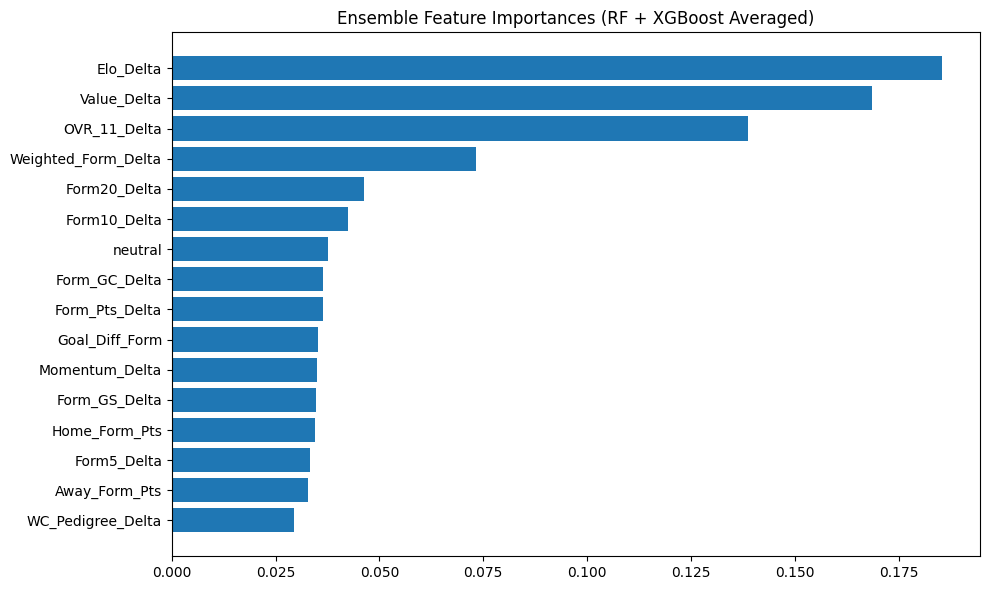

In [10]:
xgb_importances = []
rf_importances = []

# Dig into the Isotonic Calibrator
for c in clf.calibrated_classifiers_:
    voting_clf = c.estimator if hasattr(c, 'estimator') else c.base_estimator
    
    # Dig into the Voting Classifier to grab the tree models
    xgb_model = voting_clf.named_estimators_['xgb']
    rf_model = voting_clf.named_estimators_['rf']
    
    xgb_importances.append(xgb_model.feature_importances_)
    rf_importances.append(rf_model.feature_importances_)

# Average everything together
avg_xgb = np.mean(xgb_importances, axis=0)
avg_rf = np.mean(rf_importances, axis=0)
final_importance = (avg_xgb + avg_rf) / 2

importance = pd.DataFrame({"Feature": clf.feature_names_in_, "Importance": final_importance}).sort_values("Importance", ascending=False)
display(importance)

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Ensemble Feature Importances (RF + XGBoost Averaged)")
plt.tight_layout()
plt.show()

In [11]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from collections import Counter
import pandas as pd

fixtures_df = pd.read_csv(DATA_DIR / "world_cup_2026_fixtures.csv")
for col in ["Group", "Home", "Away"]: fixtures_df[col] = fixtures_df[col].astype(str).str.strip()
groups = pd.concat([fixtures_df[["Group", "Home"]].rename(columns={"Home": "Team"}), fixtures_df[["Group", "Away"]].rename(columns={"Away": "Team"})]).drop_duplicates().sort_values(["Group", "Team"])

N_SIMS = 5000

# 1. Wrap a single simulation so we can send it to multiple CPU cores
def run_single_sim(sim_id):
    result = simulate_world_cup(groups, fixtures_df, team_profiles, clf, reg_home, reg_away, deterministic=False)
    
    # Return just the results we need to save memory
    return {
        "Champion": result["Champion"],
        "R32": [t for t in result["Round32"] if t],
        "R16": result["Round16"],
        "QF": result["Quarterfinals"],
        "SF": result["Semifinals"],
        "Final": result["Finalists"]
    }

print(f"\nPHASE 1: Running {N_SIMS} Monte Carlo Simulations...")

# 2. RUN IN PARALLEL! (n_jobs=-1 uses 100% of your CPU power)
sim_results = Parallel(n_jobs=-1)(
    delayed(run_single_sim)(i) for i in tqdm(range(N_SIMS), desc="Simulating World Cups")
)

# 3. Aggregate the results from all the cores
team_stats = {team: {"R32": 0, "R16": 0, "QF": 0, "SF": 0, "Final": 0, "Champion": 0} for team in groups["Team"].unique()}
champions = Counter()

for res in sim_results:
    champ = res["Champion"]
    if champ: 
        champions[champ] += 1
        team_stats[champ]["Champion"] += 1
    
    for key in ["R32", "R16", "QF", "SF", "Final"]:
        for team in res[key]:
            if team: team_stats[team][key] += 1

print("\n" + "="*50)
print(" MONTE CARLO WORLD CUP WIN PROBABILITIES ")
print("="*50)
for team, count in champions.most_common(15): 
    print(f"{team:<20} {100 * count / N_SIMS:.2f}%")

# Save probabilities to CSV
for team in team_stats:
    for stage in team_stats[team]: 
        team_stats[team][stage] = round(100 * team_stats[team][stage] / N_SIMS, 2)

pd.DataFrame.from_dict(team_stats, orient='index').to_csv(DATA_DIR / "monte_carlo_probabilities.csv")
print("\nProbabilities saved to /data/monte_carlo_probabilities.csv!")


PHASE 1: Running 5000 Monte Carlo Simulations...


Simulating World Cups:   0%|          | 0/5000 [00:00<?, ?it/s]


 MONTE CARLO WORLD CUP WIN PROBABILITIES 
Brazil               13.84%
Spain                13.12%
France               12.72%
Germany              9.62%
Argentina            9.60%
England              7.92%
Netherlands          7.20%
Belgium              3.76%
Portugal             3.60%
Uruguay              3.38%
Mexico               2.74%
Morocco              2.02%
Switzerland          1.92%
Senegal              1.68%
Colombia             1.48%

Probabilities saved to /data/monte_carlo_probabilities.csv!


In [12]:
print("\n" + " "*50 + "\n Phase 2: Probabilistic Tournament Path Modeling \n" + " "*50)
best_path = simulate_world_cup(groups, fixtures_df, team_profiles, clf, reg_home, reg_away, deterministic=True)

print("\n---  ROUND OF 16  ---")
for i in range(0, len(best_path["Round16"]), 2): print(f"{best_path['Round16'][i]} vs {best_path['Round16'][i+1]}")
print("\n---  QUARTERFINALS  ---")
for i in range(0, len(best_path["Quarterfinals"]), 2): print(f"{best_path['Quarterfinals'][i]} vs {best_path['Quarterfinals'][i+1]}")
print("\n---  SEMIFINALS  ---")
print(f"{best_path['Semifinals'][0]} vs {best_path['Semifinals'][1]}\n{best_path['Semifinals'][2]} vs {best_path['Semifinals'][3]}")
print("\n---  FINAL  ---")
print(f"{best_path['Finalists'][0]} vs {best_path['Finalists'][1]}")
print("\n" + " "*50 + f"\n PREDICTED 2026 CHAMPION: {best_path['Champion']} \n" + " "*50)

matches_df = pd.DataFrame(best_path["Matches"])
if "Group" not in matches_df.columns: matches_df["Group"] = ""
matches_df["Group"] = matches_df["Group"].fillna("")
matches_df[["Stage", "Group", "Home", "Away", "HomeGoals", "AwayGoals", "Winner", "HomeWinProb", "DrawProb", "AwayWinProb"]].to_csv(DATA_DIR / "highest_probability_matches.csv", index=False)

all_tables = []
for group_name, table in best_path["GroupTables"].items():
    table = table.copy()
    table.insert(0, "Group", group_name)
    table.insert(1, "Team", table.index)
    all_tables.append(table)
pd.concat(all_tables).to_csv(DATA_DIR / "highest_probability_groups.csv", index=False)

print("\nPipeline finished successfully! Outputs saved to /data.")


                                                  
 Phase 2: Probabilistic Tournament Path Modeling 
                                                  

---  ROUND OF 16  ---
Mexico vs Canada
Brazil vs Turkey
Germany vs Netherlands
Belgium vs Spain
Switzerland vs Morocco
Ecuador vs Uruguay
France vs Portugal
Argentina vs England

---  QUARTERFINALS  ---
Mexico vs Brazil
Germany vs Spain
Switzerland vs Uruguay
France vs Argentina

---  SEMIFINALS  ---
Brazil vs Spain
Uruguay vs Argentina

---  FINAL  ---
Spain vs Argentina

                                                  
 PREDICTED 2026 CHAMPION: Spain 
                                                  

Pipeline finished successfully! Outputs saved to /data.
